In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import linkage, leaves_list

size = 10
data = np.random.randn(size, size)
corr_matrix = np.corrcoef(data, rowvar=False)

In [57]:
df_corr = pd.DataFrame(data=corr_matrix, 
                  columns=['One','Two', 'Three', 'Four', 'Five', 'Six', 'Seven', 'Eight', 'Nine', 'Ten'], 
                  index = ['One','Two', 'Three', 'Four', 'Five', 'Six', 'Seven', 'Eight', 'Nine', 'Ten']
                 )


def plot_correlation_matrix_df(df_corr: pd.DataFrame, 
                               cluster_reordering=True, 
                               hide_upper_triangle=True, 
                               rotation=45):

    if cluster_reordering:
        # Perform hierarchical clustering
        # Compute the linkage matrix
        Z = linkage(df_corr, method='ward')
        
        # Get the order of the columns
        ordered_columns = leaves_list(Z)
        
        # Reorder the correlation matrix
        df_corr = df_corr.iloc[ordered_columns, ordered_columns]
    
    # Create a mask for the upper triangle
    # np.triu(np.ones_like(df_corr, dtype=bool)) if hide_upper_triangle else 
    mask = np.ones_like(df_corr, dtype=bool)
    
    # Create a custom diverging colormap
    cmap = sns.diverging_palette(10, 240, as_cmap=True)
    
    # Initialize the matplotlib figure
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Draw the heatmap with the mask and correct aspect ratio
    sns.heatmap(df_corr, 
                mask=mask,
                cmap=cmap, center=0, vmin=-1, vmax=1,
                square=True, linewidths=0.5, cbar_kws={"shrink": 1,}, annot=False, fmt='.2f')
    
    # Rotate the bottom labels
    ax.set_xticklabels(ax.get_xticklabels(), 
                       rotation=rotation, 
                       verticalalignment='top', 
                       horizontalalignment='right')
    ax.set_yticklabels(ax.get_yticklabels(), 
                       rotation=rotation, 
                       verticalalignment='top', 
                       horizontalalignment='right')
    
    # Add circles
    for i in range(df_corr.shape[0]):
        for j in range(i if hide_upper_triangle else 0, df_corr.shape[1]):
            if i==j:
                continue
                
            corr = df_corr.iloc[i, j] 
            # TODO check I'm not screwing up the ordering
            
            color = cmap((corr + 1) / 2)  # Scale color from -1 to 1
            size = abs(corr)

            # TODO check I'm not screwing up the ordering
            circle = plt.Circle((i + 0.5, j + 0.5), size * 0.5, 
                                color=color, 
                                ec='black', 
                                lw=0.5)
            ax.add_patch(circle)
            
    # Customize the axes
    ax.set_xticks(np.arange(df_corr.shape[1]) + 0.5)
    ax.set_yticks(np.arange(df_corr.shape[0]) + 0.5)

    return ax, df_corr.columns

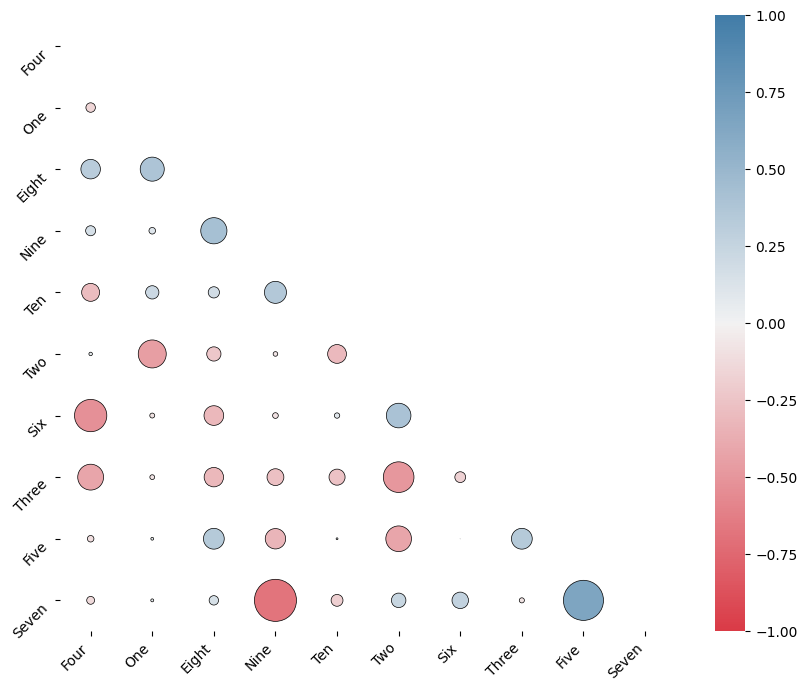

In [58]:
plot_correlation_matrix_df(df_corr, cluster_reordering=True)
plt.show()

(<Axes: >,
 Index(['One', 'Two', 'Three', 'Four', 'Five', 'Six', 'Seven', 'Eight', 'Nine',
        'Ten'],
       dtype='object'))

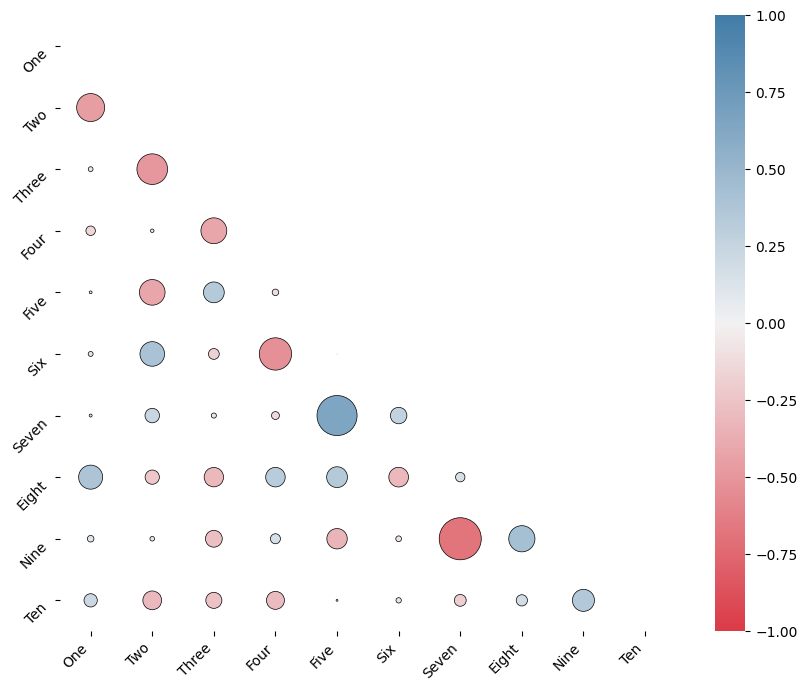

In [59]:
plot_correlation_matrix_df(df_corr, cluster_reordering=False, hide_upper_triangle=True)

(<Axes: >,
 Index(['Four', 'One', 'Eight', 'Nine', 'Ten', 'Two', 'Six', 'Three', 'Five',
        'Seven'],
       dtype='object'))

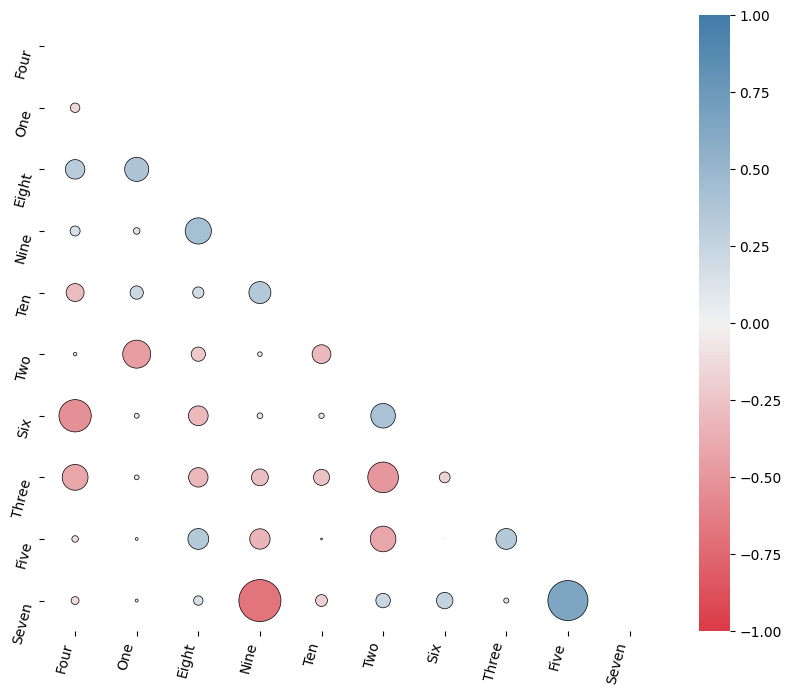

In [60]:
plot_correlation_matrix_df(df_corr, cluster_reordering=True, hide_upper_triangle=True, rotation=75)

In [61]:
df_corr_unsymettric = df_corr.copy()

df_corr_unsymettric.loc["Six", ["One", "Three"]]= 0.9

In [62]:
df_corr_unsymettric

,One,Two,Three,Four,Five,Six,Seven,Eight,Nine,Ten
One,1.000000,-0.454467,-0.077671,-0.153993,0.045675,-0.079987,0.047791,0.390401,0.107016,0.215607
Two,-0.454467,1.000000,-0.497475,0.056756,-0.416255,0.399025,0.235348,-0.231270,-0.074613,-0.304987
Three,-0.077671,-0.497475,1.000000,-0.419514,0.337625,-0.175741,-0.082792,-0.315106,-0.273154,-0.260646
Four,-0.153993,0.056756,-0.419514,1.000000,-0.105980,-0.524428,-0.128030,0.316791,0.162728,-0.291650
Five,0.045675,-0.416255,0.337625,-0.105980,1.000000,0.001405,0.650681,0.337601,-0.331008,0.030146
Six,0.900000,0.399025,0.900000,-0.524428,0.001405,1.000000,0.267404,-0.319319,-0.092706,0.087244
Seven,0.047791,0.235348,-0.082792,-0.128030,0.650681,0.267404,1.000000,0.152721,-0.682790,-0.192749
Eight,0.390401,-0.231270,-0.315106,0.316791,0.337601,-0.319319,0.152721,1.000000,0.425054,0.182535
Nine,0.107016,-0.074613,-0.273154,0.162728,-0.331008,-0.092706,-0.682790,0.425054,1.000000,0.357512
Ten,0.215607,-0.304987,-0.260646,-0.291650,0.030146,0.087244,-0.192749,0.182535,0.357512,1.000000


(<Axes: >,
 Index(['Six', 'Three', 'Five', 'Seven', 'One', 'Eight', 'Nine', 'Ten', 'Two',
        'Four'],
       dtype='object'))

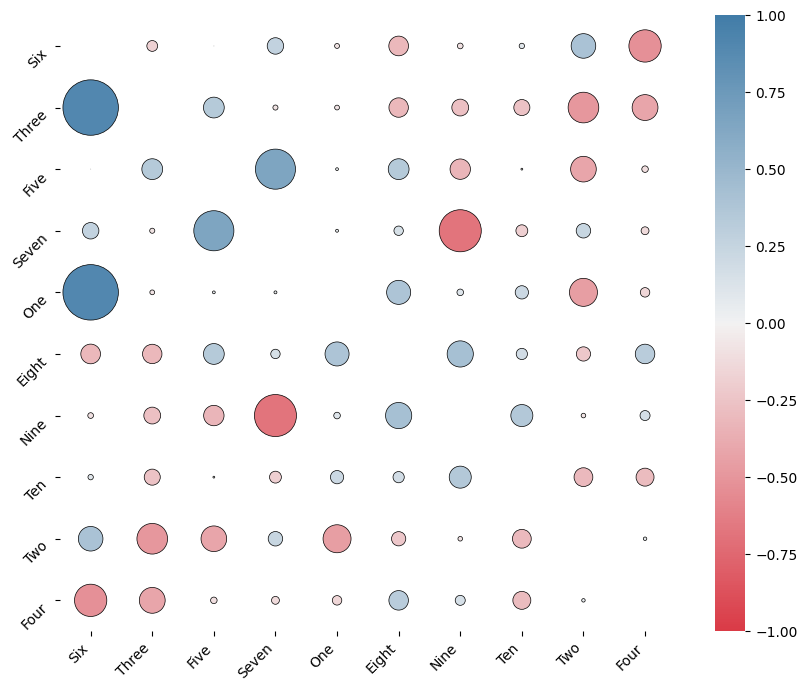

In [63]:
plot_correlation_matrix_df(df_corr_unsymettric, cluster_reordering=True, hide_upper_triangle=False)